# Bible Verse Classification

Can a machine learning model learn to distinguish Old Testament from New Testament verses — or even identify the specific book a verse came from? In this notebook we:

1. Load and parse the King James Bible into individual verses
2. Explore word frequency patterns across all 66 books (Zipf's Law)
3. Build three text representations: Count Vectors, TF-IDF, and Sentence Embeddings
4. **Testament classification** — predict OT vs NT using all three representations
5. **Book classification** — predict which of the 66 books a verse comes from
6. Interactively classify any verse in real time

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option("display.precision", 2)

plt.style.use('dark_background')

## 1. Load and Parse the Bible

The King James Bible text file has one verse per line in the format:

```
BookName chapter:verse    verse text
```

A regular expression extracts the book name and verse text. Text is cleaned (lowercased, punctuation stripped) and stored in two structures:

- `books` — nested dict `{book → {chapter → {verse → text}}}` (used for word frequency analysis)
- `df` — flat DataFrame with one row per verse and columns `book`, `chapter`, `verse`, `text`, `testament` (used for classification)

### Read the Text File

Open `bible.txt` and print the first 1,000 characters to confirm the format before parsing.

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'
data_folder = data_folder + "Text Processing/"

with open(data_folder + 'bible.txt') as f:
    text = f.read()

print(text[:1000])

Genesis 1:1	In the beginning God created the heaven and the earth.
Genesis 1:2	And the earth was without form, and void; and darkness [was] upon the face of the deep. And the Spirit of God moved upon the face of the waters.
Genesis 1:3	And God said, Let there be light: and there was light.
Genesis 1:4	And God saw the light, that [it was] good: and God divided the light from the darkness.
Genesis 1:5	And God called the light Day, and the darkness he called Night. And the evening and the morning were the first day.
Genesis 1:6	And God said, Let there be a firmament in the midst of the waters, and let it divide the waters from the waters.
Genesis 1:7	And God made the firmament, and divided the waters which [were] under the firmament from the waters which [were] above the firmament: and it was so.
Genesis 1:8	And God called the firmament Heaven. And the evening and the morning were the second day.
Genesis 1:9	And God said, Let the waters under the heaven be gathered together unto one place

### Parse Verses into a Nested Dict

A regex extracts `book`, `chapter`, `verse`, and `text` from each line. Text is lowercased and punctuation is stripped. Result: `books[book][chapter][verse] = text`.

In [3]:
books = {}

for line in text.split('\n'):
    line = line.strip()
    if not line:
        continue

    # Match: BookName chapter:verse <whitespace> text
    m = re.match(r"^([A-Za-z0-9 ]+)\s+(\d+):(\d+)\s+(.*)$", line)
    if not m:
        continue

    book = m.group(1)
    chapter = int(m.group(2))
    verse = int(m.group(3))
    verse_text = m.group(4)
    verse_text = verse_text.lower()
    verse_text = re.sub(r'\s+', ' ', verse_text)
    verse_text = re.sub(r"[^a-z'\s]", '', verse_text)

    if book not in books:
        books[book] = {}

    if chapter not in books[book]:
        books[book][chapter] = {}

    books[book][chapter][verse] = verse_text

print(f"{len(books)} books parsed:")
print(list(books.keys()))

66 books parsed:
['Genesis', 'Exodus', 'Leviticus', 'Numbers', 'Deuteronomy', 'Joshua', 'Judges', 'Ruth', '1 Samuel', '2 Samuel', '1 Kings', '2 Kings', '1 Chronicles', '2 Chronicles', 'Ezra', 'Nehemiah', 'Esther', 'Job', 'Psalm', 'Proverbs', 'Ecclesiastes', 'Song of Solomon', 'Isaiah', 'Jeremiah', 'Lamentations', 'Ezekiel', 'Daniel', 'Hosea', 'Joel', 'Amos', 'Obadiah', 'Jonah', 'Micah', 'Nahum', 'Habakkuk', 'Zephaniah', 'Haggai', 'Zechariah', 'Malachi', 'Matthew', 'Mark', 'Luke', 'John', 'Acts', 'Romans', '1 Corinthians', '2 Corinthians', 'Galatians', 'Ephesians', 'Philippians', 'Colossians', '1 Thessalonians', '2 Thessalonians', '1 Timothy', '2 Timothy', 'Titus', 'Philemon', 'Hebrews', 'James', '1 Peter', '2 Peter', '1 John', '2 John', '3 John', 'Jude', 'Revelation']


### Spot-check a Verse

Confirm the dict is structured correctly by accessing one specific verse by book, chapter, and verse number.

In [4]:
books['Genesis'][1][1]

'in the beginning god created the heaven and the earth'

### Build the DataFrame

Flatten the nested dict into one row per verse and add a `testament` column (`OT` for the first 39 books, `NT` for the remaining 27).

In [5]:
rows = []
for book, chapters in books.items():
    for chapter, verses in chapters.items():
        for verse, text in verses.items():
            rows.append({'book': book, 'chapter': chapter, 'verse': verse, 'text': text})

df = pd.DataFrame(rows)
df['testament'] = df['book'].apply(lambda x: 'OT' if x in list(books.keys())[:39] else 'NT')
df

,book,chapter,verse,text,testament
0,Genesis,1,1,in the beginning god created the heaven and th...,OT
1,Genesis,1,2,and the earth was without form and void and da...,OT
2,Genesis,1,3,and god said let there be light and there was ...,OT
3,Genesis,1,4,and god saw the light that it was good and god...,OT
4,Genesis,1,5,and god called the light day and the darkness ...,OT
...,...,...,...,...,...
31097,Revelation,22,17,and the spirit and the bride say come and let ...,NT
31098,Revelation,22,18,for i testify unto every man that heareth the ...,NT
31099,Revelation,22,19,and if any man shall take away from the words ...,NT
31100,Revelation,22,20,he which testifieth these things saith surely ...,NT


## 2. Explore: Word Frequencies (Zipf's Law)

Zipf's Law states that word frequency is roughly inversely proportional to its rank — a handful of words appear everywhere, most appear rarely. This pattern holds in nearly every natural language corpus. Each subplot below shows the log-log frequency distribution for one Bible book.

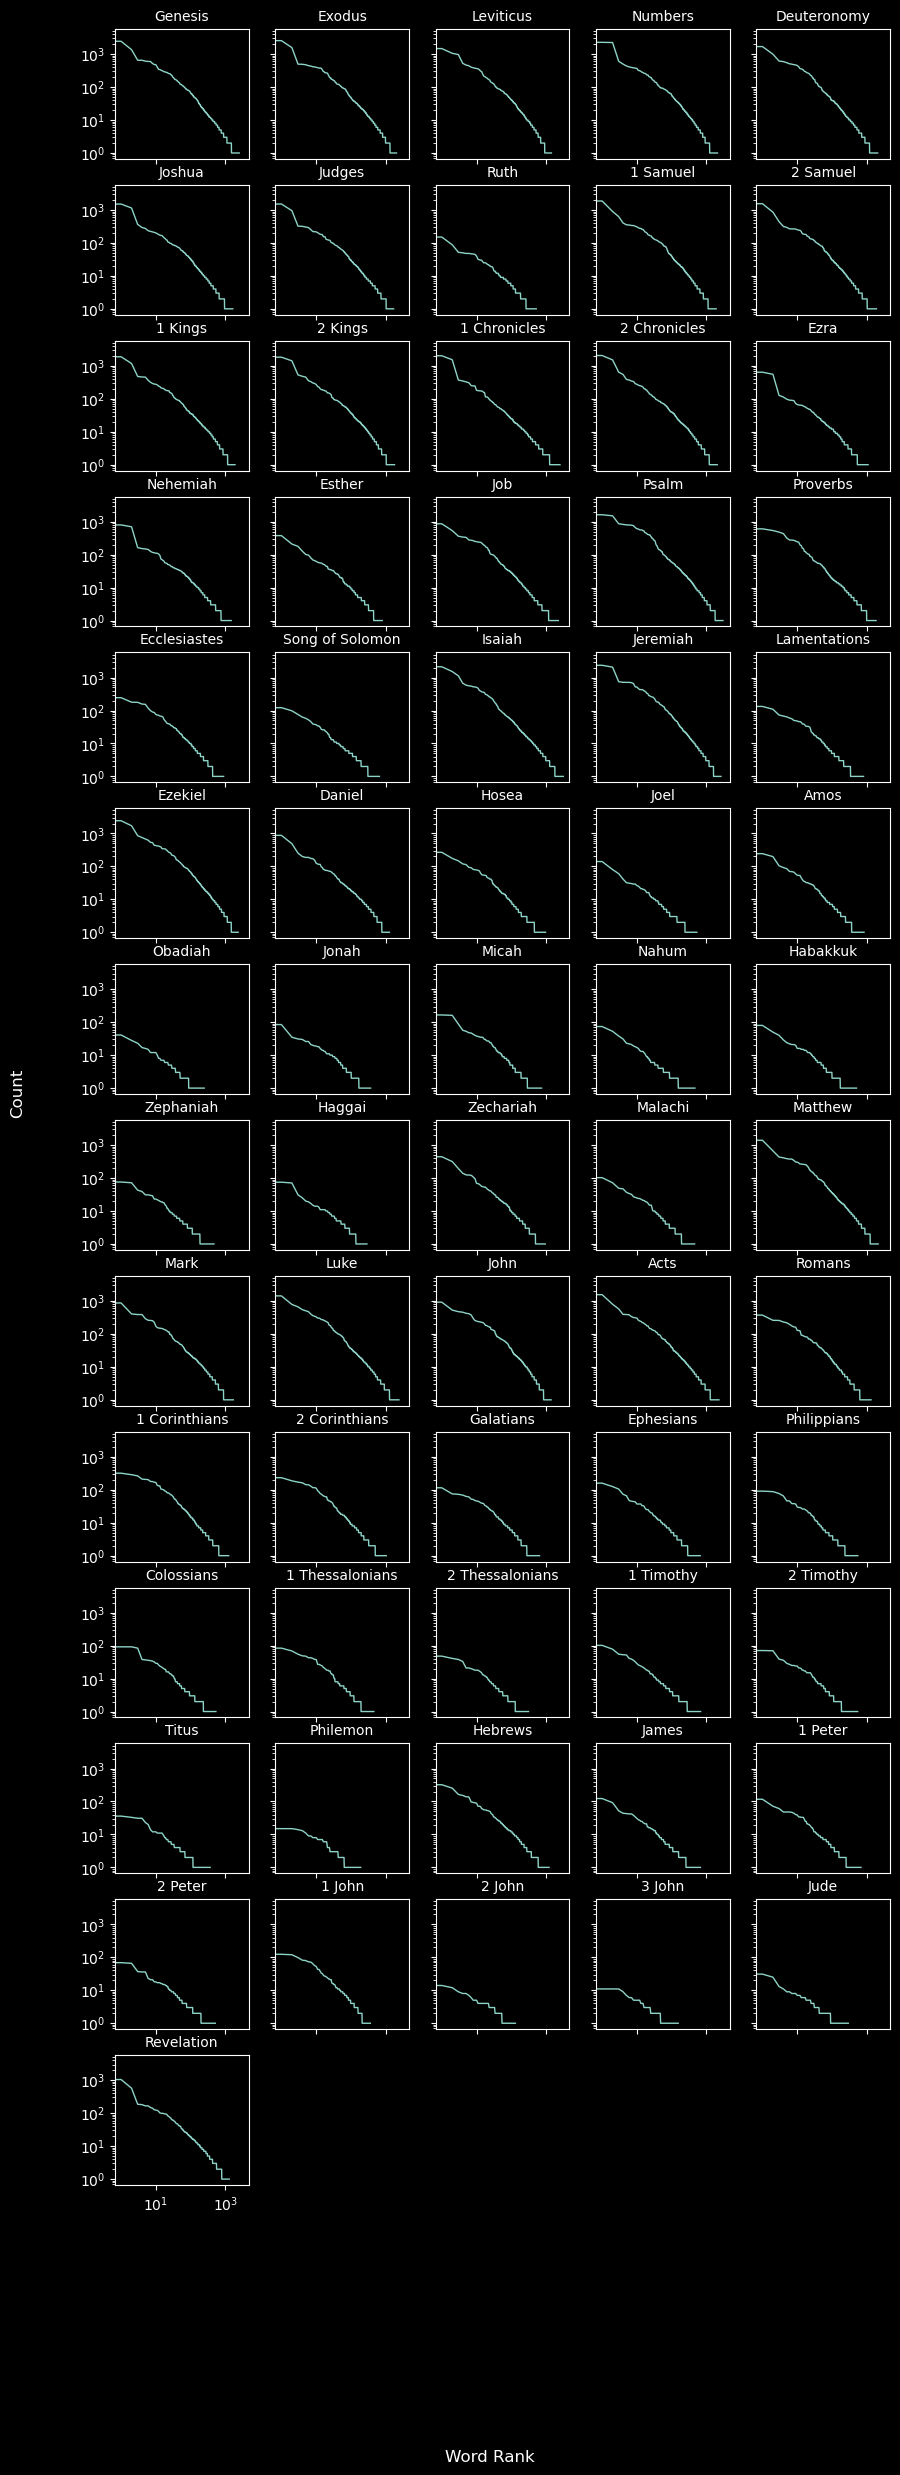

In [6]:
words_all = {}

for book in books.keys():
    for chapter in books[book].keys():
        for verse in books[book][chapter].keys():
            verse_text = books[book][chapter][verse]
            if book not in words_all:
                words_all[book] = []
            words_all[book].extend(verse_text.split())  
    words_all[book] = pd.Series(words_all[book])

book_names = list(words_all.keys())
n_books = len(book_names)

# Choose grid shape (roughly square)
n_cols = 5
n_rows = int(np.ceil(n_books / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

for ax, book in zip(axes, books):
    vc = words_all[book].value_counts()
    ax.loglog(vc.values, linewidth=1)
    ax.set_title(book, fontsize=10)

# Remove unused axes
for ax in axes[len(books):]:
    ax.axis("off")

fig.supxlabel("Word Rank")
fig.supylabel("Count")

plt.show()

## 3. Vectorizations & Embeddings

Before classifying, we convert each verse to a numeric vector. We build three representations and reuse them across both classification tasks below:

| Variable | Method | Description |
|----------|--------|-------------|
| `X_cv` | Count Vectors | Raw term counts — simple baseline |
| `X_tfidf` | TF-IDF | Down-weights common words, highlights distinctive ones |
| `X_emb` | Sentence Embeddings | Dense 384-dim vectors from `all-MiniLM-L6-v2`; captures semantics beyond word overlap |

### Count Vectors

`CountVectorizer` counts how many times each of the 5,000 most common unigrams and bigrams appears in a verse. Simple, fast, and interpretable — but treats every word occurrence equally regardless of how common it is across the corpus.

In [7]:
cv = CountVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)
X_cv = cv.fit_transform(df['text'])
print(f"X_cv shape: {X_cv.shape}")

X_cv shape: (31102, 5000)


### TF-IDF

`TfidfVectorizer` applies the same vocabulary but down-weights terms that appear in many documents. Words distinctive to a specific verse receive higher scores than filler words like "and" or "the".

In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)
X_tfidf = tfidf.fit_transform(df['text'])
print(f"X_tfidf shape: {X_tfidf.shape}")

X_tfidf shape: (31102, 5000)


### Sentence Embeddings

`all-MiniLM-L6-v2` encodes each verse into a 384-dimensional dense vector that captures semantic meaning, not just word overlap. Encoding all 31k verses takes roughly a minute.

In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')
X_emb = model.encode(df['text'].tolist(), show_progress_bar=True)
print(f"X_emb shape: {X_emb.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/972 [00:00<?, ?it/s]

X_emb shape: (31102, 384)


### Visualizing the embeddings

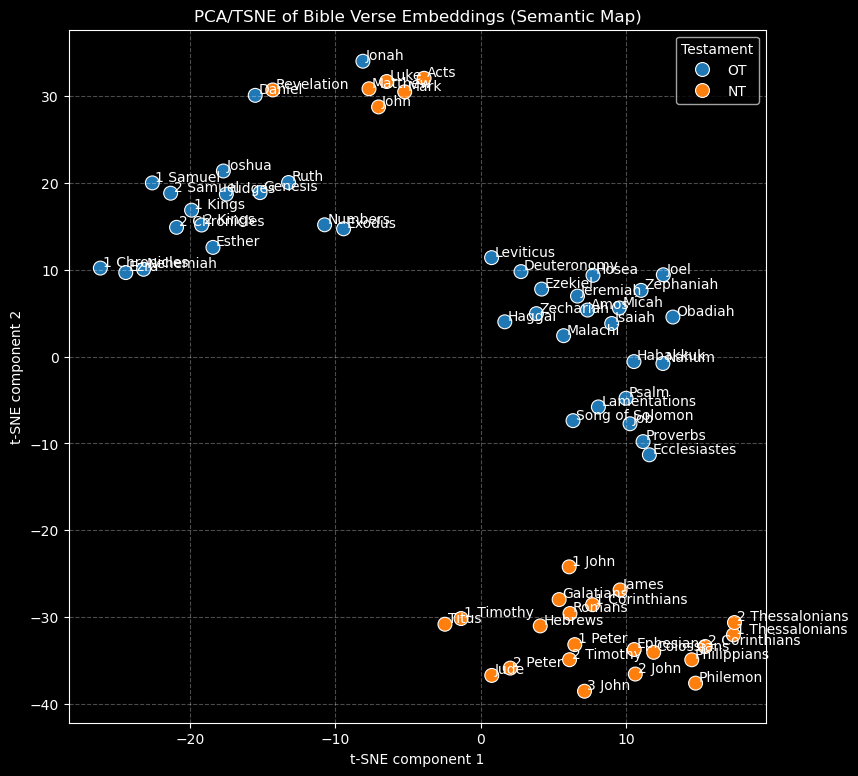

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 5. PREPARE PLOTTING DATAFRAME
emb_cols = [f'emb_{i}' for i in range(X_emb.shape[1])]
df_emb = pd.DataFrame(X_emb, columns=emb_cols)
df_emb['book'] = df['book']
df_emb['testament'] = df['testament']

# 6. DIMENSIONALITY REDUCTION (PER BOOK)
X_emb_mean = df_emb.groupby('book')[emb_cols].mean()
book_testaments = df_emb.groupby('book')['testament'].first()

pca = PCA(n_components=25)
X_pca = pca.fit_transform(X_emb_mean)

tsne = TSNE(n_components=2, perplexity=5)
X_tsne = tsne.fit_transform(X_pca)

# 7. VISUALIZATION
plt.figure(figsize=(9, 9))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=book_testaments.values,
    palette={'OT': 'tab:blue', 'NT': 'tab:orange'},
    s=100
)

for i, book_name in enumerate(book_testaments.index):
    plt.text(
        X_tsne[i, 0] + 0.2, 
        X_tsne[i, 1] + 0.2, 
        book_name, 
        fontsize=10,
    )

plt.title("PCA/TSNE of Bible Verse Embeddings (Semantic Map)")
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.legend(title="Testament")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## 4. Testament Classification: Old Testament vs New Testament

The 39 Old Testament books and 27 New Testament books have distinct vocabularies. OT centers on law, prophecy, and Israelite history; NT introduces Jesus, the apostles, and the Christian epistles.

The corpus is **unbalanced** (~24k OT verses vs ~7k NT). Each classifier block below trains two models on the same split and compares them on the held-out test set:
- **No SMOTE** — standard training on the imbalanced split
- **SMOTE** — training split resampled with Synthetic Minority Over-Sampling Technique to equalize class counts before fitting

### Count Vectors

Without SMOTE:
              precision    recall  f1-score   support

          NT       0.89      0.79      0.84      1592
          OT       0.93      0.97      0.95      4629

    accuracy                           0.92      6221
   macro avg       0.91      0.88      0.89      6221
weighted avg       0.92      0.92      0.92      6221

With SMOTE:
              precision    recall  f1-score   support

          NT       0.76      0.86      0.81      1592
          OT       0.95      0.91      0.93      4629

    accuracy                           0.90      6221
   macro avg       0.86      0.88      0.87      6221
weighted avg       0.90      0.90      0.90      6221



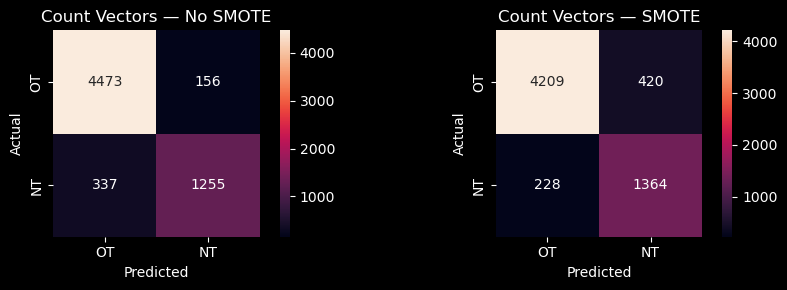

In [11]:
y = df['testament']
X_train, X_test, y_train, y_test = train_test_split(X_cv, y, test_size=0.2, random_state=42, stratify=y)

# Without SMOTE
clf_cv_test_base = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf_cv_test_base.fit(X_train, y_train)
y_pred_base = clf_cv_test_base.predict(X_test)

# With SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)
clf_cv_test_smote = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf_cv_test_smote.fit(X_res, y_res)
y_pred_smote = clf_cv_test_smote.predict(X_test)

print("Without SMOTE:")
print(classification_report(y_test, y_pred_base))
print("With SMOTE:")
print(classification_report(y_test, y_pred_smote))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, y_pred, title in zip(axes,
                              [y_pred_base, y_pred_smote],
                              ['Count Vectors — No SMOTE', 'Count Vectors — SMOTE']):
    cm = confusion_matrix(y_test, y_pred, labels=['OT', 'NT'])
    cm_df = pd.DataFrame(cm, index=['OT', 'NT'], columns=['OT', 'NT'])
    sns.heatmap(cm_df, annot=True, fmt='d', square=True, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
plt.tight_layout()
plt.show()

### TF-IDF

Without SMOTE:
              precision    recall  f1-score   support

          NT       0.93      0.72      0.81      1592
          OT       0.91      0.98      0.94      4629

    accuracy                           0.91      6221
   macro avg       0.92      0.85      0.88      6221
weighted avg       0.91      0.91      0.91      6221

With SMOTE:
              precision    recall  f1-score   support

          NT       0.77      0.86      0.81      1592
          OT       0.95      0.91      0.93      4629

    accuracy                           0.90      6221
   macro avg       0.86      0.88      0.87      6221
weighted avg       0.90      0.90      0.90      6221



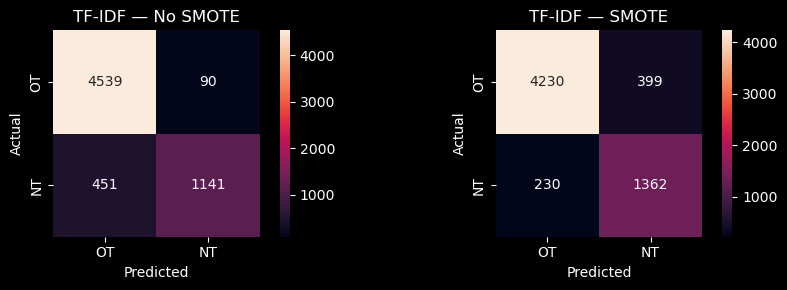

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Without SMOTE
clf_tfidf_test_base = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf_tfidf_test_base.fit(X_train, y_train)
y_pred_base = clf_tfidf_test_base.predict(X_test)

# With SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)
clf_tfidf_test_smote = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf_tfidf_test_smote.fit(X_res, y_res)
y_pred_smote = clf_tfidf_test_smote.predict(X_test)

print("Without SMOTE:")
print(classification_report(y_test, y_pred_base))
print("With SMOTE:")
print(classification_report(y_test, y_pred_smote))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, y_pred, title in zip(axes,
                              [y_pred_base, y_pred_smote],
                              ['TF-IDF — No SMOTE', 'TF-IDF — SMOTE']):
    cm = confusion_matrix(y_test, y_pred, labels=['OT', 'NT'])
    cm_df = pd.DataFrame(cm, index=['OT', 'NT'], columns=['OT', 'NT'])
    sns.heatmap(cm_df, annot=True, fmt='d', square=True, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
plt.tight_layout()
plt.show()

### TF-IDF: Coefficient Inspection

The logistic regression coefficient for each word shows how strongly it predicts OT (positive) vs NT (negative). Large absolute values identify the most diagnostic words.

C:\Users\Graham West\AppData\Local\Temp\ipykernel_27268\2275451904.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data.sort_values('coefficient'), x='coefficient', y='word', palette='vlag')


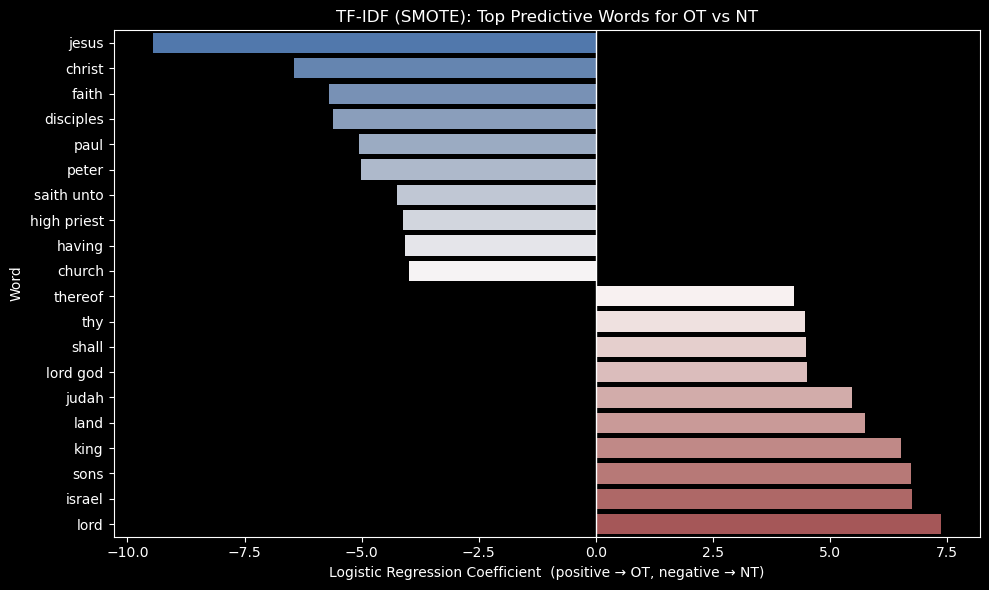

In [13]:
feature_names = tfidf.get_feature_names_out()
coefs = clf_tfidf_test_smote.coef_[0]
coef_df = pd.DataFrame({'word': feature_names, 'coefficient': coefs})

top_positive = coef_df.nlargest(10, 'coefficient')
top_negative = coef_df.nsmallest(10, 'coefficient')
plot_data = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data.sort_values('coefficient'), x='coefficient', y='word', palette='vlag')
plt.title('TF-IDF (SMOTE): Top Predictive Words for OT vs NT')
plt.xlabel('Logistic Regression Coefficient  (positive → OT, negative → NT)')
plt.ylabel('Word')
plt.axvline(0, color='white', lw=1)
plt.tight_layout()
plt.show()

### TF-IDF: Word Frequency by Testament

Cross-check the top coefficients against raw verse counts to confirm the model is picking up genuine distributional differences, not artifacts of the vocabulary or weighting.

In [14]:
feature_names = tfidf.get_feature_names_out()
coefs = clf_tfidf_test_smote.coef_[0]
coef_df = pd.DataFrame({'word': feature_names, 'coefficient': coefs})

top_10 = coef_df.nlargest(10, 'coefficient')
bottom_10 = coef_df.nsmallest(10, 'coefficient')
target_df = pd.concat([top_10, bottom_10])

results = []
for _, row in target_df.iterrows():
    word = row['word']
    coef = row['coefficient']
    pattern = rf'\b{re.escape(word)}\b'
    ot_count = df[df['testament'] == 'OT']['text'].str.contains(pattern).sum()
    nt_count = df[df['testament'] == 'NT']['text'].str.contains(pattern).sum()
    results.append({'word': word, 'OT_Verses': ot_count, 'NT_Verses': nt_count,
                    'Total_Verses': ot_count + nt_count, 'coefficient': coef})

results_df = pd.DataFrame(results).sort_values('coefficient')
print(results_df)

           word  OT_Verses  NT_Verses  Total_Verses  coefficient
10        jesus          0        942           942        -9.46
11       christ          0        522           522        -6.43
12        faith          2        229           231        -5.70
13    disciples          1        231           232        -5.60
14         paul          0        153           153        -5.05
15        peter          0        153           153        -5.01
16   saith unto          4        167           171        -4.25
17  high priest         20         52            72        -4.11
18       having         36        150           186        -4.06
19       church          0         76            76        -3.98
9       thereof        669         38           707         4.24
8           thy       2733        311          3044         4.47
7         shall       5060       1001          6061         4.49
6      lord god        519         13           532         4.50
5         judah        75

### Sentence Embeddings

Without SMOTE:
              precision    recall  f1-score   support

          NT       0.81      0.65      0.72      1592
          OT       0.89      0.95      0.92      4629

    accuracy                           0.87      6221
   macro avg       0.85      0.80      0.82      6221
weighted avg       0.87      0.87      0.87      6221

With SMOTE:
              precision    recall  f1-score   support

          NT       0.65      0.81      0.73      1592
          OT       0.93      0.85      0.89      4629

    accuracy                           0.84      6221
   macro avg       0.79      0.83      0.81      6221
weighted avg       0.86      0.84      0.85      6221



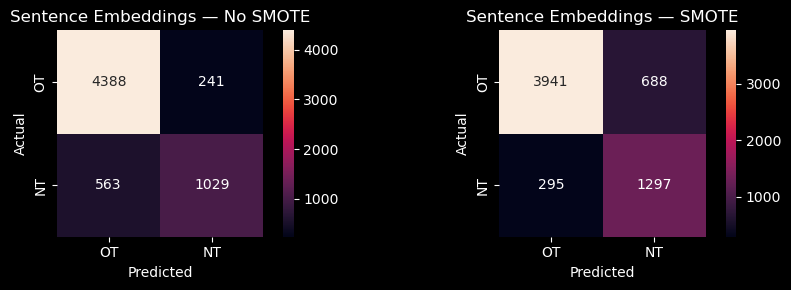

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_emb, y, test_size=0.2, random_state=42, stratify=y)

# Without SMOTE
clf_emb_test_base = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf_emb_test_base.fit(X_train, y_train)
y_pred_base = clf_emb_test_base.predict(X_test)

# With SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)
clf_emb_test_smote = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
clf_emb_test_smote.fit(X_res, y_res)
y_pred_smote = clf_emb_test_smote.predict(X_test)

print("Without SMOTE:")
print(classification_report(y_test, y_pred_base))
print("With SMOTE:")
print(classification_report(y_test, y_pred_smote))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, y_pred, title in zip(axes,
                              [y_pred_base, y_pred_smote],
                              ['Sentence Embeddings — No SMOTE', 'Sentence Embeddings — SMOTE']):
    cm = confusion_matrix(y_test, y_pred, labels=['OT', 'NT'])
    cm_df = pd.DataFrame(cm, index=['OT', 'NT'], columns=['OT', 'NT'])
    sns.heatmap(cm_df, annot=True, fmt='d', square=True, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Interactive Demo: Classify a Verse (OT vs NT)

Re-run the cell below to sample a random verse and see how each model classifies it.

In [16]:
sample = df.sample(1).iloc[0]
verse_input = sample['text']
print(f"{sample['book']} {sample['chapter']}:{sample['verse']}:")
print(f"  Text: {verse_input}")
print(f"  Actual: {sample['testament']}\n")

for name, vec, clf in [
    ('Count Vectors', cv,    clf_cv_test_smote),
    ('TF-IDF',        tfidf, clf_tfidf_test_smote),
    ('Embeddings',    None,  clf_emb_test_smote),
]:
    x = model.encode([verse_input]) if name == 'Embeddings' else vec.transform([verse_input])
    pred = clf.predict(x)[0]
    probs = pd.Series(clf.predict_proba(x)[0], index=clf.classes_)
    print(f"  {name:14s}: predicted={pred}  |  " +
          "  ".join(f"{c}: {p:.2f}" for c, p in probs.items()))

Proverbs 7:19:
  Text: for the goodman is not at home he is gone a long journey
  Actual: OT

  Count Vectors : predicted=OT  |  NT: 0.42  OT: 0.58
  TF-IDF        : predicted=NT  |  NT: 0.60  OT: 0.40
  Embeddings    : predicted=NT  |  NT: 0.54  OT: 0.46


## 5. Book Classification: Which of the 66 Books?

Now we tackle a harder 66-class problem — predicting the specific Bible book a verse comes from. Books vary enormously in size (Psalms has 2,461 verses; 2 John has 13), so performance varies widely.

Each block trains **two models** — one on the raw imbalanced split and one with **SMOTE** oversampling — so you can see whether balancing helps minority books. The per-book recall bar charts make the before/after difference easy to spot.

### Count Vectors

Without SMOTE:
                 precision    recall  f1-score   support

   1 Chronicles       0.50      0.55      0.52       188
  1 Corinthians       0.35      0.46      0.40        87
         1 John       0.27      0.19      0.22        21
        1 Kings       0.52      0.47      0.49       163
        1 Peter       0.44      0.19      0.27        21
       1 Samuel       0.73      0.65      0.69       162
1 Thessalonians       0.29      0.11      0.16        18
      1 Timothy       0.50      0.17      0.26        23
   2 Chronicles       0.43      0.39      0.41       164
  2 Corinthians       0.39      0.27      0.32        51
         2 John       0.00      0.00      0.00         2
        2 Kings       0.56      0.48      0.51       144
        2 Peter       0.67      0.17      0.27        12
       2 Samuel       0.53      0.40      0.45       139
2 Thessalonians       0.00      0.00      0.00         9
      2 Timothy       0.00      0.00      0.00        17
         3 John

c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

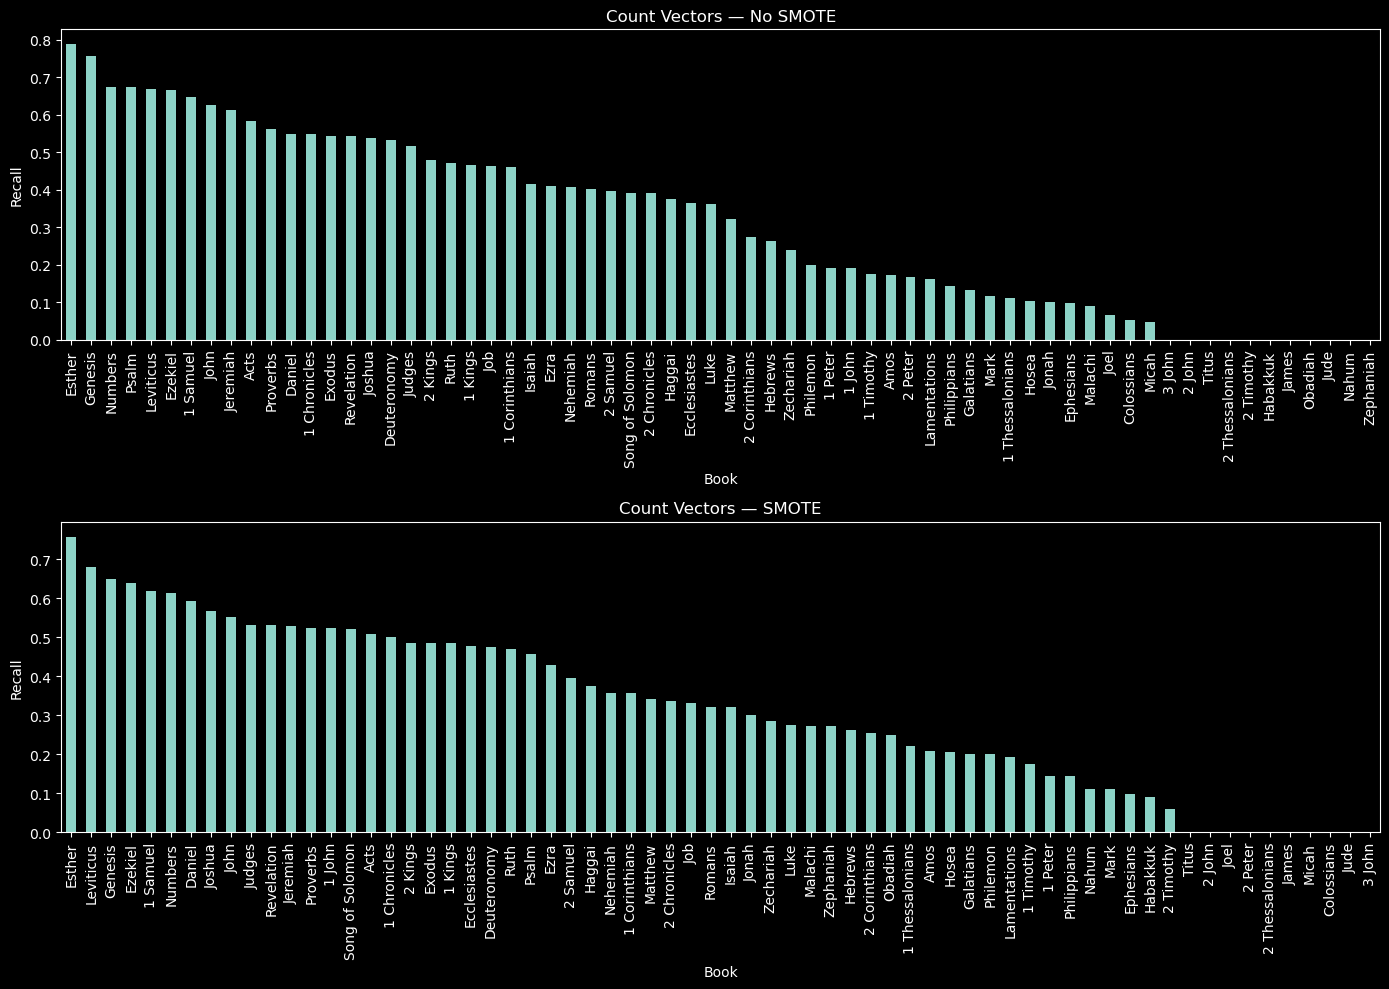

In [17]:
y_book = df['book']
X_train, X_test, y_train, y_test = train_test_split(X_cv, y_book, test_size=0.2, random_state=42, stratify=y_book)

# Without SMOTE
clf_cv_book_base = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf_cv_book_base.fit(X_train, y_train)
y_pred_base = clf_cv_book_base.predict(X_test)

# With SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)
clf_cv_book_smote = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf_cv_book_smote.fit(X_res, y_res)
y_pred_smote = clf_cv_book_smote.predict(X_test)

print("Without SMOTE:")
print(classification_report(y_test, y_pred_base))
print("\nWith SMOTE:")
print(classification_report(y_test, y_pred_smote))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax, y_pred, title in zip(axes,
                              [y_pred_base, y_pred_smote],
                              ['Count Vectors — No SMOTE', 'Count Vectors — SMOTE']):
    report = classification_report(y_test, y_pred, output_dict=True)
    book_recall = {k: v['recall'] for k, v in report.items() if k not in ('accuracy', 'macro avg', 'weighted avg')}
    pd.Series(book_recall).sort_values(ascending=False).plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Recall')
    ax.set_xlabel('Book')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### TF-IDF

Without SMOTE:
                 precision    recall  f1-score   support

   1 Chronicles       0.52      0.56      0.54       188
  1 Corinthians       0.35      0.34      0.35        87
         1 John       0.67      0.10      0.17        21
        1 Kings       0.56      0.41      0.48       163
        1 Peter       0.00      0.00      0.00        21
       1 Samuel       0.76      0.62      0.68       162
1 Thessalonians       0.00      0.00      0.00        18
      1 Timothy       0.00      0.00      0.00        23
   2 Chronicles       0.41      0.37      0.39       164
  2 Corinthians       0.44      0.14      0.21        51
         2 John       0.00      0.00      0.00         2
        2 Kings       0.57      0.48      0.52       144
        2 Peter       0.00      0.00      0.00        12
       2 Samuel       0.60      0.40      0.48       139
2 Thessalonians       0.00      0.00      0.00         9
      2 Timothy       0.00      0.00      0.00        17
         3 John

c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

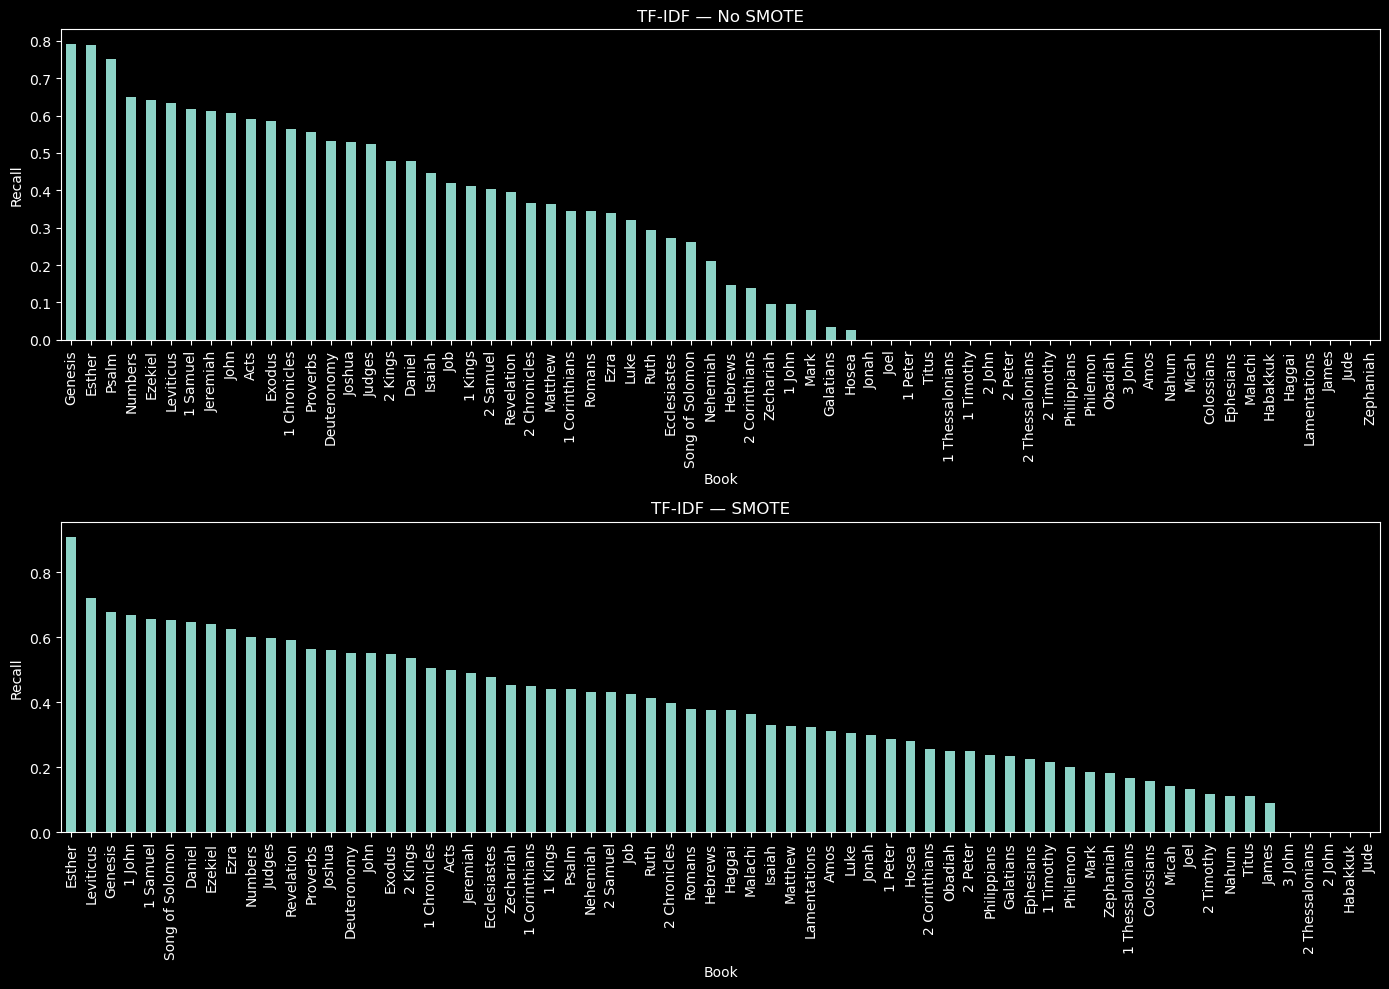

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_book, test_size=0.2, random_state=42, stratify=y_book)

# Without SMOTE
clf_tfidf_book_base = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf_tfidf_book_base.fit(X_train, y_train)
y_pred_base = clf_tfidf_book_base.predict(X_test)

# With SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)
clf_tfidf_book_smote = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf_tfidf_book_smote.fit(X_res, y_res)
y_pred_smote = clf_tfidf_book_smote.predict(X_test)

print("Without SMOTE:")
print(classification_report(y_test, y_pred_base))
print("\nWith SMOTE:")
print(classification_report(y_test, y_pred_smote))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax, y_pred, title in zip(axes,
                              [y_pred_base, y_pred_smote],
                              ['TF-IDF — No SMOTE', 'TF-IDF — SMOTE']):
    report = classification_report(y_test, y_pred, output_dict=True)
    book_recall = {k: v['recall'] for k, v in report.items() if k not in ('accuracy', 'macro avg', 'weighted avg')}
    pd.Series(book_recall).sort_values(ascending=False).plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Recall')
    ax.set_xlabel('Book')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### Sentence Embeddings

Without SMOTE:
                 precision    recall  f1-score   support

   1 Chronicles       0.45      0.53      0.49       188
  1 Corinthians       0.38      0.39      0.39        87
         1 John       0.75      0.29      0.41        21
        1 Kings       0.50      0.32      0.39       163
        1 Peter       0.00      0.00      0.00        21
       1 Samuel       0.63      0.61      0.62       162
1 Thessalonians       0.00      0.00      0.00        18
      1 Timothy       0.67      0.09      0.15        23
   2 Chronicles       0.41      0.42      0.42       164
  2 Corinthians       0.27      0.18      0.21        51
         2 John       0.00      0.00      0.00         2
        2 Kings       0.49      0.47      0.48       144
        2 Peter       0.00      0.00      0.00        12
       2 Samuel       0.44      0.32      0.37       139
2 Thessalonians       0.00      0.00      0.00         9
      2 Timothy       0.00      0.00      0.00        17
         3 John

c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Graham West\anaconda3\envs\msds565\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

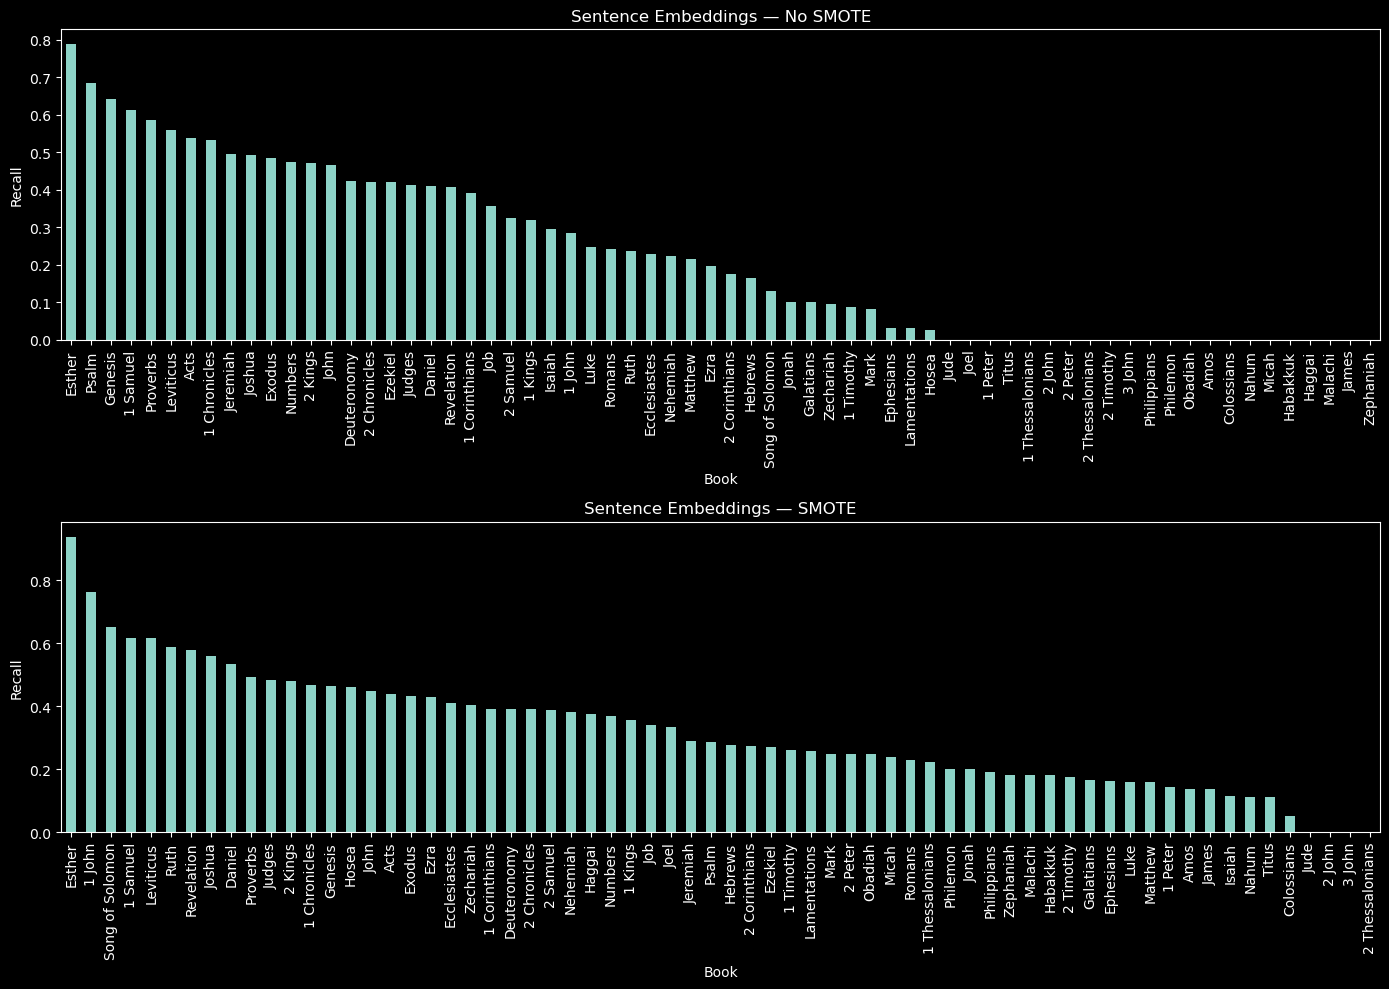

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_emb, y_book, test_size=0.2, random_state=42, stratify=y_book)

# Without SMOTE
clf_emb_book_base = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf_emb_book_base.fit(X_train, y_train)
y_pred_base = clf_emb_book_base.predict(X_test)

# With SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_train, y_train)
clf_emb_book_smote = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs')
clf_emb_book_smote.fit(X_res, y_res)
y_pred_smote = clf_emb_book_smote.predict(X_test)

print("Without SMOTE:")
print(classification_report(y_test, y_pred_base))
print("\nWith SMOTE:")
print(classification_report(y_test, y_pred_smote))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax, y_pred, title in zip(axes,
                              [y_pred_base, y_pred_smote],
                              ['Sentence Embeddings — No SMOTE', 'Sentence Embeddings — SMOTE']):
    report = classification_report(y_test, y_pred, output_dict=True)
    book_recall = {k: v['recall'] for k, v in report.items() if k not in ('accuracy', 'macro avg', 'weighted avg')}
    pd.Series(book_recall).sort_values(ascending=False).plot(kind='bar', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Recall')
    ax.set_xlabel('Book')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### Interactive Demo: Identify the Book

Re-run the cell below to sample a random verse and see which book each model predicts, along with the top-5 candidates.

In [20]:
sample = df.sample(1).iloc[0]
verse_input = sample['text']
print(f"{sample['book']} {sample['chapter']}:{sample['verse']}:")
print(f"  Text: {verse_input}")
print(f"  Actual book: {sample['book']}\n")

for name, vec, clf in [
    ('Count Vectors', cv,    clf_cv_book_smote),
    ('TF-IDF',        tfidf, clf_tfidf_book_smote),
    ('Embeddings',    None,  clf_emb_book_smote),
]:
    x = model.encode([verse_input]) if name == 'Embeddings' else vec.transform([verse_input])
    pred = clf.predict(x)[0]
    probs = pd.Series(clf.predict_proba(x)[0], index=clf.classes_)
    top = probs.nlargest(5)
    print(f"  {name:14s}: {pred}")
    for book, prob in top.items():
        print(f"       {book:<14s}: {prob:.3f}")

Proverbs 7:5:
  Text: that they may keep thee from the strange woman from the stranger which flattereth with her words
  Actual book: Proverbs

  Count Vectors : Proverbs
       Proverbs      : 0.874
       Deuteronomy   : 0.031
       Job           : 0.027
       1 Timothy     : 0.011
       Ruth          : 0.009
  TF-IDF        : Proverbs
       Proverbs      : 0.787
       Deuteronomy   : 0.033
       Job           : 0.030
       Ecclesiastes  : 0.009
       Jeremiah      : 0.009
  Embeddings    : Proverbs
       Proverbs      : 0.278
       Ruth          : 0.188
       2 Timothy     : 0.073
       Philemon      : 0.054
       Ezekiel       : 0.050
